# **Introdução ao Aprendizado Profundo (TCE11616)**

Prof. Diogo Lima

Nessa aula, implementaremos uma regressão linear de **três formas diferentes**, cada
uma mais próxima de como se treina uma rede neural de verdade.

**Ideia central da aula:** um modelo é uma *família* de equações

$$y = f[x, \phi]$$

Treinar é escolher o membro $\hat{\phi}$ que minimiza uma **função de perda** $\mathcal{L}[\phi]$ sobre os dados de treinamento.

## 0. Preparação do ambiente

Se estiver no Google Colab, o PyTorch já vem instalado. Localmente, use:

```bash
pip install torch matplotlib numpy
```

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

SEED = 42 # Fixando uma semente aleatória para garantir reproducibilidade
torch.manual_seed(SEED)

---
## 1. Tensores: o objeto básico do PyTorch

Um **tensor** é um array multidimensional, muito parecido com o `ndarray` do NumPy.

A diferença que importa para nós é que o tensor sabe **rastrear operações** para calcular derivadas automaticamente e pode viver na GPU.

In [14]:
# Criando tensores
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(2, 3)
c = torch.randn(2, 3)      # valores vindos de uma dist. normal padrão

print(f'a = {a}')
print(f'b = {b}')
print(f'c = {c}')
print(f'shape de b: {b.shape}')
print(f'tipo de c: {c.dtype}')


a = tensor([1., 2., 3.])
b = tensor([[0., 0., 0.],
        [0., 0., 0.]])
c = tensor([[-2.4752, -0.9316, -0.1335],
        [ 0.3415, -0.0716, -0.0909]])
shape de b: torch.Size([2, 3])
tipo de c: torch.float32


In [10]:
# Operações são vetorizadas, como no NumPy
x = torch.tensor([1.0, 2.0, 3.0, 4.0])

print("x * 2      =", x * 2)
print("x ** 2     =", x ** 2)
print("soma       =", x.sum())
print("média      =", x.mean())

x * 2      = tensor([2., 4., 6., 8.])
x ** 2     = tensor([ 1.,  4.,  9., 16.])
soma       = tensor(10.)
média      = tensor(2.5000)


In [11]:
# Ida e volta com NumPy
arr = np.array([10.0, 20.0, 30.0])
t = torch.from_numpy(arr)          # NumPy -> tensor
de_volta = t.numpy()               # tensor -> NumPy

print(t, type(t))
print(de_volta, type(de_volta))

tensor([10., 20., 30.], dtype=torch.float64) <class 'torch.Tensor'>
[10. 20. 30.] <class 'numpy.ndarray'>


### Atenção ao `shape`

Boa parte dos erros iniciais em PyTorch vem de dimensões incompatíveis. 

Uma convenção que usaremos sempre: a **primeira dimensão é o número de exemplos**.

Ou seja, um conjunto com 80 exemplos e 1 característica tem shape `(80, 1)`. 

Os vetores devem ser transformados usando o método .reshape(-1,1).

In [12]:
v = torch.randn(80)              # vetor: shape (80,)
m = v.reshape(-1, 1)             # matriz coluna: shape (80, 1)

print("v.shape =", v.shape)
print("m.shape =", m.shape)

v.shape = torch.Size([80])
m.shape = torch.Size([80, 1])


---
## 2. O conjunto de dados da aula

Vamos gerar 100 exemplos a partir de uma relação linear com ruído gaussiano:

$$ y = 1{,}5 + 0{,}8\,x + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1) $$

Note que conhecemos a resposta verdadeira ($\phi_0 = 1{,}5$ e $\phi_1 = 0{,}8$) porque **nós** geramos os dados. Isso é um luxo que não existe em problemas reais, mas é ótimo para verificar se nosso treinamento funciona.

In [15]:
rng = np.random.default_rng(SEED) # rgn um gerador de números aleatórios com semente aleatória travada

N = 100
x_np = rng.uniform(0, 10, N)
y_np = 1.5 + 0.8 * x_np + rng.normal(0, 1.0, N)

# Separação treino/teste ANTES de qualquer ajuste
idx = rng.permutation(N)
idx_treino, idx_teste = idx[:80], idx[80:]

x_treino, y_treino = x_np[idx_treino], y_np[idx_treino]
x_teste,  y_teste  = x_np[idx_teste],  y_np[idx_teste]

print(f"Treino: {len(x_treino)} exemplos")
print(f"Teste:  {len(x_teste)} exemplos")

Treino: 80 exemplos
Teste:  20 exemplos


### Por que separar antes?

Se olharmos os dados de teste para tomar qualquer decisão de modelagem, eles deixam de ser uma estimativa honesta de generalização. 

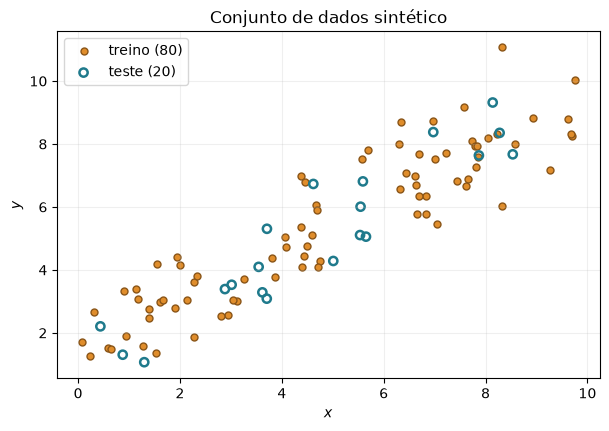

In [16]:
plt.figure(figsize=(7, 4.5))
plt.scatter(x_treino, y_treino, c="#E08D2B", s=25,
            edgecolors="#8a5518", label="treino (80)")
plt.scatter(x_teste, y_teste, facecolors="none", s=35,
            edgecolors="#1F7A8C", linewidths=1.8, label="teste (20)")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Conjunto de dados sintético")
plt.legend(); plt.grid(alpha=0.2)
plt.show()

### Convertendo para tensores

O PyTorch trabalha por padrão em `float32`, enquanto o NumPy usa `float64`. Converter
explicitamente evita erros de tipo mais adiante.

In [17]:
X_treino = torch.tensor(x_treino, dtype=torch.float32).reshape(-1, 1)
Y_treino = torch.tensor(y_treino, dtype=torch.float32).reshape(-1, 1)
X_teste  = torch.tensor(x_teste,  dtype=torch.float32).reshape(-1, 1)
Y_teste  = torch.tensor(y_teste,  dtype=torch.float32).reshape(-1, 1)

print("X_treino:", X_treino.shape, "| Y_treino:", Y_treino.shape)

X_treino: torch.Size([80, 1]) | Y_treino: torch.Size([80, 1])


---
## 3. A função de perda, calculada à mão

Antes de treinar qualquer coisa, vamos **avaliar** as três retas da tabela dos slides.
A perda de mínimos quadrados é

$$ \mathcal{L}[\phi] = \sum_{i=1}^{I} \big(\phi_0 + \phi_1 x_i - y_i\big)^2 $$

In [18]:
def modelo(X, phi0, phi1):
    return phi0 + phi1 * X


def perda_soma(X, Y, phi0, phi1):
    """SOMA dos quadrados dos desvios)."""
    residuos = modelo(X, phi0, phi1) - Y
    return (residuos ** 2).sum()


def perda_media(X, Y, phi0, phi1):
    """ (MSE) Erro quadrado médio."""
    residuos = modelo(X, phi0, phi1) - Y
    return (residuos ** 2).mean()

**Vejamos a performance para três retas candidatas:**

In [20]:
candidatas = [
    ("(a) inclinação baixa demais", 4.50, 0.30),
    ("(b) inclinação alta demais",  0.20, 1.15),
    ("(c) mínimos quadrados",       1.59, 0.79),
]

In [21]:
print(f"{'Reta':<30} {'phi0':>6} {'phi1':>6} {'L treino':>10} {'L/I tr':>8} {'L/I te':>8}")
print("-" * 72)

for nome, p0, p1 in candidatas:
    Ltr  = perda_soma(X_treino, Y_treino, p0, p1).item()
    mtr  = perda_media(X_treino, Y_treino, p0, p1).item()
    mte  = perda_media(X_teste,  Y_teste,  p0, p1).item()
    print(f"{nome:<30} {p0:>6.2f} {p1:>6.2f} {Ltr:>10.1f} {mtr:>8.2f} {mte:>8.2f}")

Reta                             phi0   phi1   L treino   L/I tr   L/I te
------------------------------------------------------------------------
(a) inclinação baixa demais      4.50   0.30      248.7     3.11     3.60
(b) inclinação alta demais       0.20   1.15      174.2     2.18     1.30
(c) mínimos quadrados            1.59   0.79       78.4     0.98     0.90


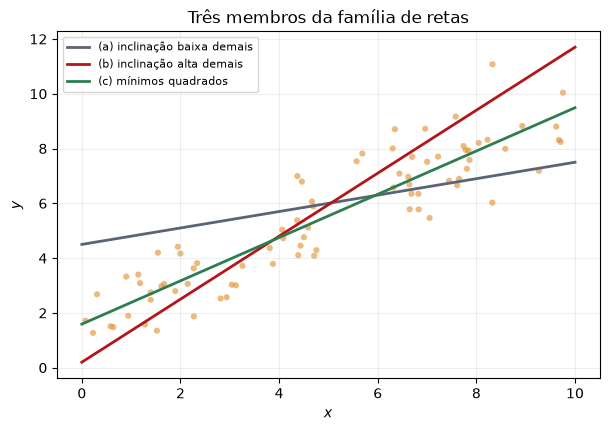

In [22]:
grade_x = torch.linspace(0, 10, 100).reshape(-1, 1)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_treino, y_treino, c="#E08D2B", s=20, alpha=0.6, edgecolors="none")
cores = ["#5B6472", "#B3151A", "#2E7D4F"]
for (nome, p0, p1), cor in zip(candidatas, cores):
    plt.plot(grade_x, modelo(grade_x, p0, p1), color=cor, lw=2, label=nome)
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Três membros da família de retas")
plt.legend(fontsize=8); plt.grid(alpha=0.2)
plt.show()

---
## 4. `autograd`: o PyTorch calcula as derivadas por você

O treinamento foi descrito na aula como "descer a superfície de perda". 

Para isso precisamos do **gradiente**: as derivadas parciais$\partial \mathcal{L} / \partial \phi_0$ e $\partial \mathcal{L} / \partial \phi_1$


Veja o **Problema 2.1** do livro.

Calcular derivadas à mão é viável para uma reta com 2 parâmetros. Para uma rede com milhões de parâmetros, não é. É por isso que o PyTorch existe.

Marcamos um tensor com `requires_grad=True` e ele passa a **registrar** todas as operações. 

Ao chamar `.backward()`, o PyTorch percorre esse registro de trás para frente e preenche o campo `.grad`.

In [33]:
# Exemplo mínimo, para ver o mecanismo funcionando
w = torch.tensor(3.0, requires_grad=True)
z = w ** 2 + 5 * w          # z = w^2 + 5w  =>  dz/dw = 2w + 5

z.backward()
print("z      =", z.item())
print("dz/dw  =", w.grad.item(), "   (esperado: 2*3 + 5 = 11)")

z      = 24.0
dz/dw  = 11.0    (esperado: 2*3 + 5 = 11)


### Verificando o Problema 2.1 numericamente

As derivadas da perda de mínimos quadrados são:

$$\frac{\partial \mathcal{L}}{\partial \phi_0} = \sum_i 2\big(\phi_0 + \phi_1 x_i - y_i\big)
\qquad
\frac{\partial \mathcal{L}}{\partial \phi_1} = \sum_i 2 x_i \big(\phi_0 + \phi_1 x_i - y_i\big)$$

Vamos comparar a conta manual com o que o `autograd` devolve.

In [34]:
phi0 = torch.tensor(0.0, requires_grad=True)
phi1 = torch.tensor(0.0, requires_grad=True)

L = perda_soma(X_treino, Y_treino, phi0, phi1)
L.backward()

# Conta manual (fórmulas acima)
res = (0.0 + 0.0 * X_treino) - Y_treino
manual_0 = (2 * res).sum().item()
manual_1 = (2 * X_treino * res).sum().item()

print(f"autograd:  dL/dphi0 = {phi0.grad.item():>10.3f}   dL/dphi1 = {phi1.grad.item():>10.3f}")
print(f"manual:    dL/dphi0 = {manual_0:>10.3f}   dL/dphi1 = {manual_1:>10.3f}")

autograd:  dL/dphi0 =   -870.670   dL/dphi1 =  -5251.576
manual:    dL/dphi0 =   -870.670   dL/dphi1 =  -5251.576


---
## 5. Versão 1 — gradiente descendente na mão

Agora implementamos literalmente o algoritmo dos slides:

1. Inicializar os parâmetros aleatoriamente
2. Medir o gradiente
3. Dar um passo na direção mais íngreme para baixo
4. Repetir

O tamanho do passo é a **taxa de aprendizado** (`lr`). Usamos a perda **média** (MSE) em vez da soma, porque assim a escala do gradiente não depende do número de exemplos, tornando a escolha da `lr` muito menos sensível.

In [35]:
torch.manual_seed(SEED)

# 1. Inicialização aleatória
phi0 = torch.randn(1, requires_grad=True)
phi1 = torch.randn(1, requires_grad=True)

lr = 0.01
n_epocas = 2000
historico = []

print(f"Início:  phi0 = {phi0.item():.3f}, phi1 = {phi1.item():.3f}")

for epoca in range(n_epocas):
    # ---- passo para frente: calcula a perda
    L = perda_media(X_treino, Y_treino, phi0, phi1)

    # ---- passo para trás: calcula os gradientes
    L.backward()

    # ---- atualização (sem rastrear gradientes)
    with torch.no_grad():
        phi0 -= lr * phi0.grad
        phi1 -= lr * phi1.grad

        # zerar os gradientes: eles ACUMULAM entre iterações
        phi0.grad.zero_()
        phi1.grad.zero_()

    historico.append(L.item())
    if epoca % 400 == 0:
        print(f"época {epoca:>5} | perda = {L.item():.4f} | "
              f"phi0 = {phi0.item():.3f} | phi1 = {phi1.item():.3f}")

print(f"\nFinal:   phi0 = {phi0.item():.3f}, phi1 = {phi1.item():.3f}")
print(f"Verdade: phi0 = 1.500, phi1 = 0.800")

Início:  phi0 = 0.337, phi1 = 0.129
época     0 | perda = 24.3813 | phi0 = 0.426 | phi1 = 0.670
época   400 | perda = 0.9867 | phi0 = 1.432 | phi1 = 0.811
época   800 | perda = 0.9802 | phi0 = 1.571 | phi1 = 0.789
época  1200 | perda = 0.9801 | phi0 = 1.591 | phi1 = 0.786
época  1600 | perda = 0.9801 | phi0 = 1.594 | phi1 = 0.785

Final:   phi0 = 1.595, phi1 = 0.785
Verdade: phi0 = 1.500, phi1 = 0.800


> **A armadilha do `zero_()`:** o PyTorch **acumula** gradientes em vez de
> sobrescrevê-los. Se você esquecer de zerar, o gradiente da iteração 2 será a soma
> das iterações 1 e 2, e o treinamento diverge. Esse é provavelmente o erro mais
> comum de quem está começando.

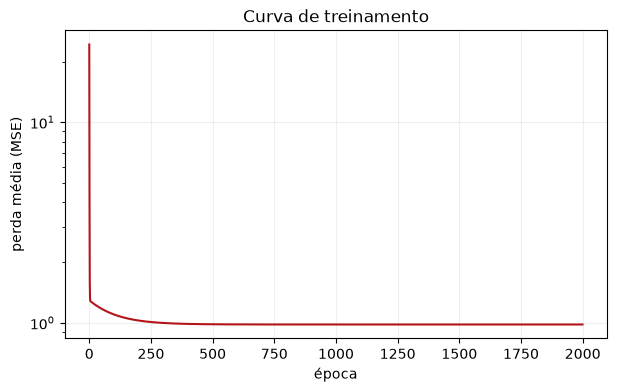

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(historico, color="#B3151A", lw=1.5)
plt.xlabel("época"); plt.ylabel("perda média (MSE)")
plt.title("Curva de treinamento")
plt.yscale("log"); plt.grid(alpha=0.2)
plt.show()

---
## 6. Versão 2 — usando `nn.Module` e um otimizador

O código acima funciona, mas não escala: imagine escrever `phi.grad.zero_()` para
cada um dos milhões de parâmetros de uma rede.

O PyTorch oferece duas abstrações que resolvem isso:

- **`nn.Linear`** — encapsula os parâmetros (aqui, `weight` = $\phi_1$ e `bias` = $\phi_0$)
- **`torch.optim`** — encapsula a regra de atualização

Este é o padrão que usaremos no resto do curso.

In [37]:
import torch.nn as nn

torch.manual_seed(SEED)

# Um modelo linear: 1 entrada -> 1 saída
modelo_nn = nn.Linear(in_features=1, out_features=1)

print("Parâmetros do modelo:")
for nome, p in modelo_nn.named_parameters():
    print(f"  {nome:<8} shape={tuple(p.shape)}  valor inicial={p.item():.3f}")

Parâmetros do modelo:
  weight   shape=(1, 1)  valor inicial=0.765
  bias     shape=(1,)  valor inicial=0.830


In [38]:
criterio = nn.MSELoss()                                   # perda média (MSE)
otimizador = torch.optim.SGD(modelo_nn.parameters(), lr=0.01)

n_epocas = 2000
hist_treino, hist_teste = [], []

for epoca in range(n_epocas):
    # ---------- treinamento
    modelo_nn.train()
    pred = modelo_nn(X_treino)
    L = criterio(pred, Y_treino)

    otimizador.zero_grad()   # zera os gradientes de TODOS os parâmetros
    L.backward()             # calcula os gradientes
    otimizador.step()        # dá o passo

    # ---------- avaliação no conjunto de teste
    modelo_nn.eval()
    with torch.no_grad():
        L_teste = criterio(modelo_nn(X_teste), Y_teste)

    hist_treino.append(L.item())
    hist_teste.append(L_teste.item())

    if epoca % 400 == 0:
        print(f"época {epoca:>5} | treino = {L.item():.4f} | teste = {L_teste.item():.4f}")

phi1_final = modelo_nn.weight.item()
phi0_final = modelo_nn.bias.item()
print(f"\nphi0 = {phi0_final:.3f}   (verdade: 1.500)")
print(f"phi1 = {phi1_final:.3f}   (verdade: 0.800)")

época     0 | treino = 1.7344 | teste = 0.8402
época   400 | treino = 0.9829 | teste = 0.8645
época   800 | treino = 0.9801 | teste = 0.8941
época  1200 | treino = 0.9801 | teste = 0.8987
época  1600 | treino = 0.9801 | teste = 0.8994

phi0 = 1.595   (verdade: 1.500)
phi1 = 0.785   (verdade: 0.800)


Compare com o resultado da Versão 1: os valores devem ser praticamente os mesmos.
A diferença é só de organização do código — o algoritmo é idêntico.

Note também as três linhas do laço de treinamento:

```python
otimizador.zero_grad()   # limpa
L.backward()             # calcula
otimizador.step()        # atualiza
```

Essa sequência aparecerá em **todos** os treinamentos do curso, de redes rasas a
*transformers*.

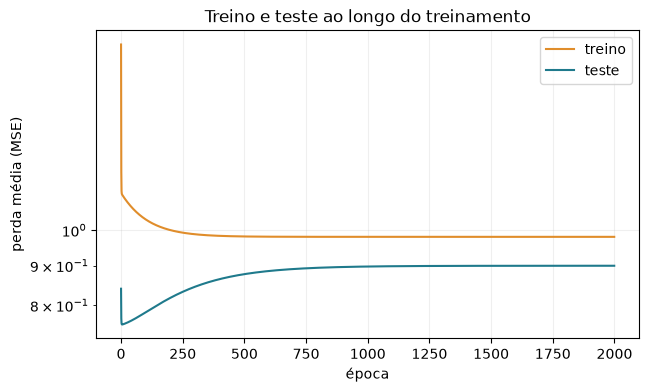

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(hist_treino, color="#E08D2B", lw=1.5, label="treino")
plt.plot(hist_teste,  color="#1F7A8C", lw=1.5, label="teste")
plt.xlabel("época"); plt.ylabel("perda média (MSE)")
plt.title("Treino e teste ao longo do treinamento")
plt.yscale("log"); plt.legend(); plt.grid(alpha=0.2)
plt.show()

> **Observe:** as duas curvas caem juntas e ficam próximas. Isso é sinal de que o
> modelo **não está sobreajustando** — o que faz sentido, já que uma reta com 2
> parâmetros é simples demais para decorar 80 pontos. Nas próximas aulas, com modelos
> muito mais expressivos, veremos essas curvas se separarem.

---
## 7. Versão 3 — a solução em forma fechada

Como discutido nos slides, para a regressão linear **não precisaríamos** de gradiente
descendente: existe solução analítica (Problema 2.2 do livro).

$$ \hat{\phi} = (X^\top X)^{-1} X^\top y $$

Usamos isso aqui apenas para **verificar** se o treinamento iterativo chegou ao lugar
certo. Para redes neurais, essa solução não existe.

In [40]:
# Matriz de projeto: coluna de 1s (para phi0) + coluna de x (para phi1)
X_proj = torch.cat([torch.ones_like(X_treino), X_treino], dim=1)

phi_fechada = torch.linalg.lstsq(X_proj, Y_treino).solution.flatten()

print(f"{'Método':<28} {'phi0':>8} {'phi1':>8}")
print("-" * 46)
print(f"{'Forma fechada':<28} {phi_fechada[0]:>8.3f} {phi_fechada[1]:>8.3f}")
print(f"{'Gradiente descendente':<28} {phi0_final:>8.3f} {phi1_final:>8.3f}")
print(f"{'Verdade (geração dos dados)':<28} {1.5:>8.3f} {0.8:>8.3f}")

Método                           phi0     phi1
----------------------------------------------
Forma fechada                   1.595    0.785
Gradiente descendente           1.595    0.785
Verdade (geração dos dados)     1.500    0.800


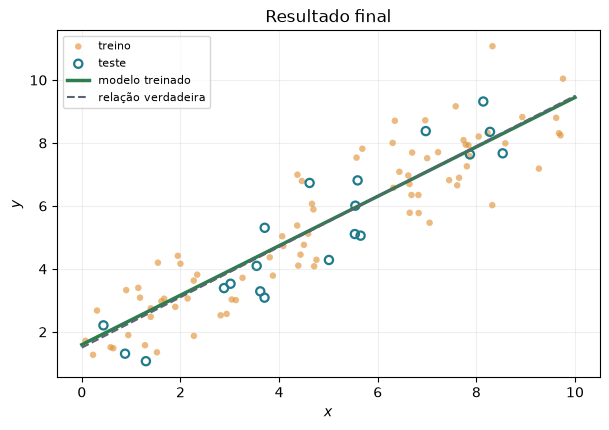

In [41]:
with torch.no_grad():
    y_grade = modelo_nn(grade_x)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_treino, y_treino, c="#E08D2B", s=22, alpha=0.6,
            edgecolors="none", label="treino")
plt.scatter(x_teste, y_teste, facecolors="none", s=35,
            edgecolors="#1F7A8C", linewidths=1.6, label="teste")
plt.plot(grade_x, y_grade, color="#2E7D4F", lw=2.5, label="modelo treinado")
plt.plot(grade_x, 1.5 + 0.8 * grade_x, "--", color="#5B6472", lw=1.5,
         label="relação verdadeira")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Resultado final")
plt.legend(fontsize=8); plt.grid(alpha=0.2)
plt.show()

---
## 8. Extrapolação: uma demonstração

Vamos ver o que acontece quando pedimos ao modelo uma predição bem longe dos dados de treinamento.

In [42]:
x_novos = torch.tensor([[5.0], [50.0], [500.0]])

with torch.no_grad():
    preds = modelo_nn(x_novos)

for xv, pv in zip(x_novos.flatten(), preds.flatten()):
    situacao = "interpolação" if 0 <= xv <= 10 else "EXTRAPOLAÇÃO"
    print(f"x = {xv:>7.1f}  ->  y = {pv:>8.2f}   ({situacao})")

x =     5.0  ->  y =     5.52   (interpolação)
x =    50.0  ->  y =    40.86   (EXTRAPOLAÇÃO)
x =   500.0  ->  y =   394.28   (EXTRAPOLAÇÃO)


Repare que o modelo **responde normalmente** nos três casos. Nenhum aviso, nenhum erro, nenhuma medida de incerteza. Retorna normalmente apenas um número (rótulo previsto).

Para $x = 500$ a predição é uma extrapolação de cinquenta vezes o alcance dos dados, sustentada unicamente pela suposição de que a relação continua linear para sempre.

**Nada nos dados justifica essa suposição.**

**A questão prática:** em produção, o modelo não sabe que está extrapolando. Cabe a quem projeta o sistema monitorar se as entradas continuam vindo da mesma distribuição dos dados de treinamento.

---
## 9. Para praticar

**1.** Altere a taxa de aprendizado para `lr = 0.001` e depois para `lr = 0.05`. O que acontece em cada caso? Quantas épocas são necessárias para convergir?

**2.** Troque `perda_media` por `perda_soma` na Versão 1, mantendo `lr = 0.01`. Explique o que acontece e por quê. *(Dica: pense na magnitude do gradiente.)*

**3.** Aumente o ruído na geração dos dados de $\sigma = 1$ para $\sigma = 4$. Os parâmetros estimados ainda se aproximam de $(1{,}5;\ 0{,}8)$? E a perda final?

**4.** Troque o otimizador `SGD` por `torch.optim.Adam` com a mesma taxa de aprendizado. Compare as curvas de treinamento.

**5.** *(Problema 2.3 do livro)* Reformule a regressão como modelo **generativo**, ajustando $x = \phi_0' + \phi_1' y$. Depois inverta para obter $y$ em função de $x$. As predições coincidem com as do modelo discriminativo? Por quê?

---
